# 챔피언 태깅용 데이터 확인

## Imports

In [1]:
import pandas as pd
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# 한글
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)


## read 챔프사전.csv

In [2]:
# read 챔프사전.csv
champ_df = pd.read_csv('챔프사전.csv', encoding='utf-8')
champ_df

,key,name,tags
0,86,가렌,"['Fighter', 'Tank']"
1,3,갈리오,"['Tank', 'Mage']"
2,41,갱플랭크,['Fighter']
3,79,그라가스,['Fighter']
4,104,그레이브즈,['Marksman']
...,...,...,...
163,114,피오라,"['Fighter', 'Assassin', 'AD']"
164,105,피즈,"['Assassin', 'Fighter', 'AP']"
165,74,하이머딩거,"['Mage', 'Support', 'AP']"
166,120,헤카림,"['Fighter', 'Tank', 'AD']"


## read 게임 데이터

In [3]:
match_dir = '../data/match/'
match_list = pd.read_csv('../data/match_id_list.csv')['match_id'].tolist()

추출할 데이터 목록

In [4]:
result_dict = {
    'championId': [],
    'totalDamageDealtToChampions': [],
    'physicalDamageDealtToChampions': [],
    'magicDamageDealtToChampions': [],
    'totalDamageTaken': [],
    'timeCCingOthers': [],
    'totalTimeCCDealt': [],
    'totalDamageShieldedOnTeammates': [],
    'totalHealsOnTeammates': [],
    'dpm': [],
    'item0': [],
    'item1': [],
    'item2': [],
    'item3': [],
    'item4': [],
    'item5': [],
    'item6': [],
    'teamPosition': []
}

In [5]:
for match_id in tqdm(match_list):
    with open(match_dir + str(match_id) + '.json', 'r') as f:
        match_data = json.load(f)
    
    if match_data['info']['gameDuration'] < 300:
        continue

    for participant in match_data['info']['participants']:
        result_dict['championId'].append(participant['championId'])
        result_dict['totalDamageDealtToChampions'].append(participant['totalDamageDealtToChampions'])
        result_dict['physicalDamageDealtToChampions'].append(participant['physicalDamageDealtToChampions'])
        result_dict['magicDamageDealtToChampions'].append(participant['magicDamageDealtToChampions'])
        result_dict['totalDamageTaken'].append(participant['totalDamageTaken'])
        result_dict['timeCCingOthers'].append(participant['timeCCingOthers'])
        result_dict['totalTimeCCDealt'].append(participant['totalTimeCCDealt'])
        result_dict['totalDamageShieldedOnTeammates'].append(participant['totalDamageShieldedOnTeammates'])
        result_dict['totalHealsOnTeammates'].append(participant['totalHealsOnTeammates'])
        result_dict['dpm'].append(participant['totalDamageDealtToChampions'] / (match_data['info']['gameDuration'] / 60))
        result_dict['item0'].append(participant['item0'])
        result_dict['item1'].append(participant['item1'])
        result_dict['item2'].append(participant['item2'])
        result_dict['item3'].append(participant['item3'])
        result_dict['item4'].append(participant['item4'])
        result_dict['item5'].append(participant['item5'])
        result_dict['item6'].append(participant['item6'])
        result_dict['teamPosition'].append(participant['teamPosition'])
        
result_df = pd.DataFrame(result_dict)
result_df

  0%|          | 0/60209 [00:00<?, ?it/s]

,championId,totalDamageDealtToChampions,physicalDamageDealtToChampions,magicDamageDealtToChampions,totalDamageTaken,timeCCingOthers,totalTimeCCDealt,totalDamageShieldedOnTeammates,totalHealsOnTeammates,dpm,item0,item1,item2,item3,item4,item5,item6,teamPosition
0,901,12469,9981,2488,6707,4,134,0,0,807.926566,3070,3009,1055,3044,3057,1036,3340,TOP
1,72,6248,4427,1546,16828,18,403,0,0,404.838013,1101,3047,3084,3067,1033,1031,3364,JUNGLE
2,517,11671,447,11035,14801,18,185,0,0,756.220302,3158,2031,3152,1056,1082,3108,3364,MIDDLE
3,81,15247,11621,3273,11124,3,67,0,0,987.926566,1055,3158,3078,3070,3133,1036,3340,BOTTOM
4,44,3735,1357,1965,8808,16,54,1155,3894,242.008639,0,3190,3877,3067,3070,1001,3364,UTILITY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598275,122,7108,6698,0,16183,12,62,0,0,304.194009,1055,3078,3047,3181,2021,2022,3364,TOP
598276,234,10750,9387,1070,31549,16,167,0,0,460.057061,6333,3047,6610,2055,0,0,3340,JUNGLE
598277,84,8334,831,6973,12804,0,47,0,0,356.661912,1056,1082,3100,3145,3067,3020,3364,MIDDLE
598278,360,15864,13729,1596,21129,2,3,0,0,678.915835,6676,3031,3035,1001,0,0,3363,BOTTOM


In [6]:
result_df.info()
# save as csv
result_df.to_csv('match_data.csv', index=False, encoding='utf-8')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598280 entries, 0 to 598279
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   championId                      598280 non-null  int64  
 1   totalDamageDealtToChampions     598280 non-null  int64  
 2   physicalDamageDealtToChampions  598280 non-null  int64  
 3   magicDamageDealtToChampions     598280 non-null  int64  
 4   totalDamageTaken                598280 non-null  int64  
 5   timeCCingOthers                 598280 non-null  int64  
 6   totalTimeCCDealt                598280 non-null  int64  
 7   totalDamageShieldedOnTeammates  598280 non-null  int64  
 8   totalHealsOnTeammates           598280 non-null  int64  
 9   dpm                             598280 non-null  float64
 10  item0                           598280 non-null  int64  
 11  item1                           598280 non-null  int64  
 12  item2           

In [7]:
# calculate average groupby championId
# 0~8 columns are numeric
cols = result_df.columns[:9]
result_avg_df = result_df[cols].groupby('championId').mean()

avgTotalDamage = result_df['totalDamageDealtToChampions'].mean()
avgTotalTaken = result_df['totalDamageTaken'].mean()
avgTimeCC = result_df['timeCCingOthers'].mean()
avgTotalTimeCC = result_df['totalTimeCCDealt'].mean()
avgTotalDamageShielded = result_df['totalDamageShieldedOnTeammates'].mean()
avgTotalHeals = result_df['totalHealsOnTeammates'].mean()

result_avg_df


,totalDamageDealtToChampions,physicalDamageDealtToChampions,magicDamageDealtToChampions,totalDamageTaken,timeCCingOthers,totalTimeCCDealt,totalDamageShieldedOnTeammates,totalHealsOnTeammates
championId,,,,,,,,
1,18750.678625,1130.240658,17038.239163,14542.417040,27.961136,235.729447,1585.502242,51.382661
2,17871.803851,13249.776775,46.587244,24403.376053,12.693141,296.788207,0.225632,0.400120
3,15339.728336,310.764857,14553.240109,21567.261733,31.604677,103.670511,982.738267,24.352074
4,15145.680000,1916.686486,12888.770811,18602.991351,31.355135,162.476216,0.000000,22.043243
5,16248.570376,14475.169182,1021.292734,34755.273429,21.157599,445.249561,0.371007,0.778168
...,...,...,...,...,...,...,...,...
897,16576.849157,13815.400976,1753.852884,26774.626176,30.935138,1083.447649,675.517569,0.615972
901,21664.085286,14770.629991,4610.328342,20218.908637,10.013672,267.675781,0.012370,0.874566
902,4551.722449,986.428571,3426.542857,12302.867347,16.165306,119.597959,5008.102041,5101.379592


In [8]:
# ap tag when
# total average of totalDamageDealtToChampions < champion average of totalDamageDealtToChampions
# total average of magicDamageDealtToChampions > champion average of magicDamageDealtToChampions

ap_champ_list = []
ad_champ_list = []
nodeal_champ_list = []
for championId in result_avg_df.index:
    if avgTotalDamage < result_avg_df.loc[championId, 'totalDamageDealtToChampions'] and \
        result_avg_df.loc[championId, 'physicalDamageDealtToChampions'] < result_avg_df.loc[championId, 'magicDamageDealtToChampions']:
        ap_champ_list.append(championId)
    elif avgTotalDamage < result_avg_df.loc[championId, 'totalDamageDealtToChampions'] and \
        result_avg_df.loc[championId, 'physicalDamageDealtToChampions'] > result_avg_df.loc[championId, 'magicDamageDealtToChampions']:
        ad_champ_list.append(championId)
    else:
        nodeal_champ_list.append(championId)
# ap tag
print('ap tag')
for championId in ap_champ_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])


# ad tag
print('ad tag')
for championId in ad_champ_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])
    
# nodeal
print('nodeal tag')
for championId in nodeal_champ_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])

ap tag
애니
르블랑
블라디미르
케일
라이즈
티모
이블린
카서스
초가스
애니비아
문도 박사
카사딘
베이가
카타리나
엘리스
오리아나
브랜드
럼블
카시오페아
하이머딩거
우디르
그라가스
모데카이저
아칼리
케넨
말자하
코그모
제라스
쉬바나
아리
피즈
빅토르
직스
리산드라
다이애나
신드라
아우렐리온 솔
조이
자이라
벨코즈
탈리야
에코
아지르
사일러스
벡스
릴리아
그웬
오로라
흐웨이
ad tag
올라프
신 짜오
우르곳
사이온
시비르
트리스타나
미스 포츈
애쉬
트린다미어
잭스
트위치
이렐리아
갱플랭크
코르키
케이틀린
레넥톤
베인
판테온
이즈리얼
요릭
탈론
리븐
그레이브즈
바루스
피오라
드레이븐
카직스
제이스
퀸
케인
카이사
나르
야스오
카밀
아크샨
진
킨드레드
제리
징크스
루시안
제드
클레드
키아나
아트록스
사미라
일라오이
칼리스타
자야
아펠리오스
요네
세트
크산테
스몰더
나피리
nodeal tag
갈리오
트위스티드 페이트
피들스틱
마스터 이
알리스타
소라카
워윅
누누와 윌럼프
모르가나
질리언
신지드
아무무
람머스
샤코
소나
잔나
카르마
타릭
트런들
스웨인
블리츠크랭크
말파이트
녹턴
마오카이
자르반 4세
오공
리 신
스카너
나서스
니달리
뽀삐
가렌
레오나
쉔
럭스
볼리베어
렝가
노틸러스
세주아니
룰루
헤카림
다리우스
세라핀
자크
벨베스
브라움
탐 켄치
브라이어
비에고
세나
바이
나미
유미
쓰레쉬
렉사이
아이번
바드
라칸
오른
니코
렐
파이크
레나타 글라스크
닐라
밀리오


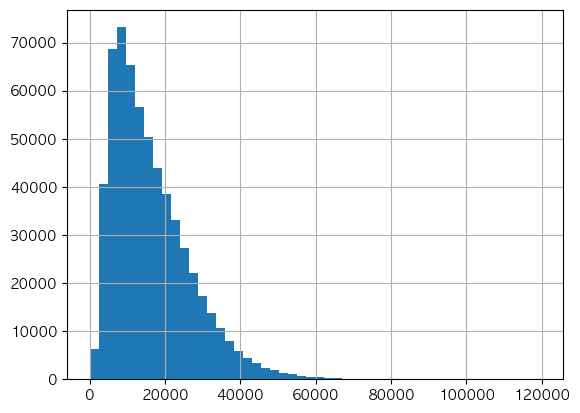

In [9]:
# hist
result_df['totalDamageDealtToChampions'].hist(bins=50)
#show
plt.show()

In [10]:
result_df['teamPosition'].unique()

array(['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY', ''], dtype=object)

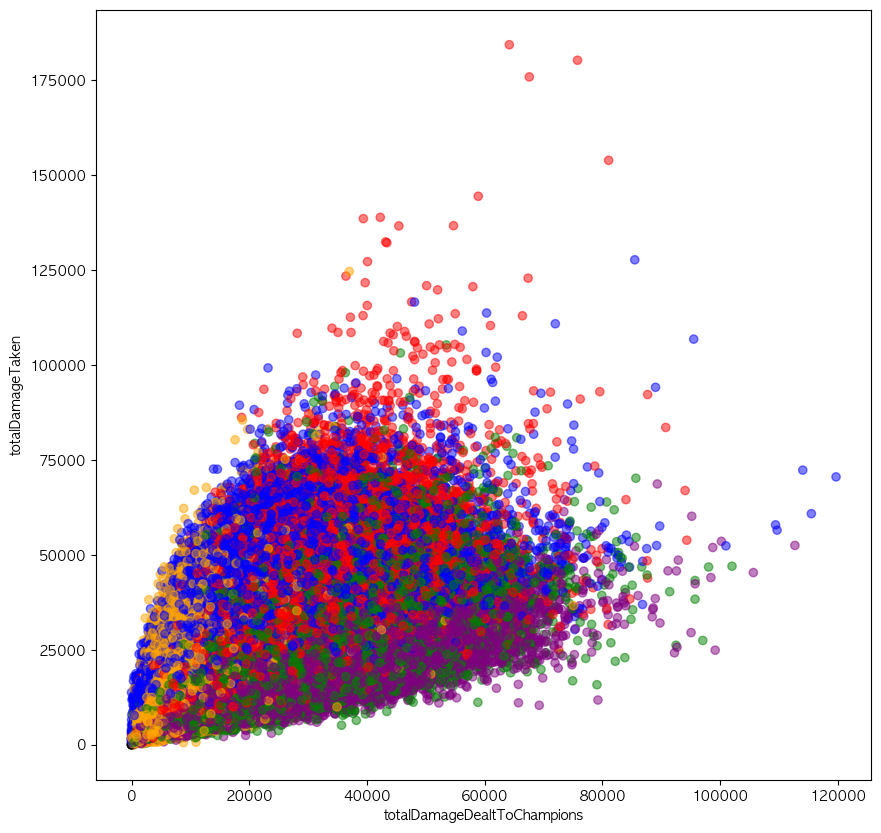

In [11]:
# scatter
# different color by teamPosition
# new column for color
# 'TOP': 'red', 'JUNGLE': 'blue', 'MID': 'green', 'BOTTOM': 'purple', 'UTILITY': 'orange', '':'black'
result_df['color'] = result_df['teamPosition'].map({'TOP': 'red', 'JUNGLE': 'blue', 'MIDDLE': 'green', 'BOTTOM': 'purple', 'UTILITY': 'orange', '':'black'})
plt.figure(figsize=(10, 10))
plt.scatter(result_df['totalDamageDealtToChampions'], result_df['totalDamageTaken'], c=result_df['color'], alpha=0.5)
plt.xlabel('totalDamageDealtToChampions')
plt.ylabel('totalDamageTaken')
plt.show()

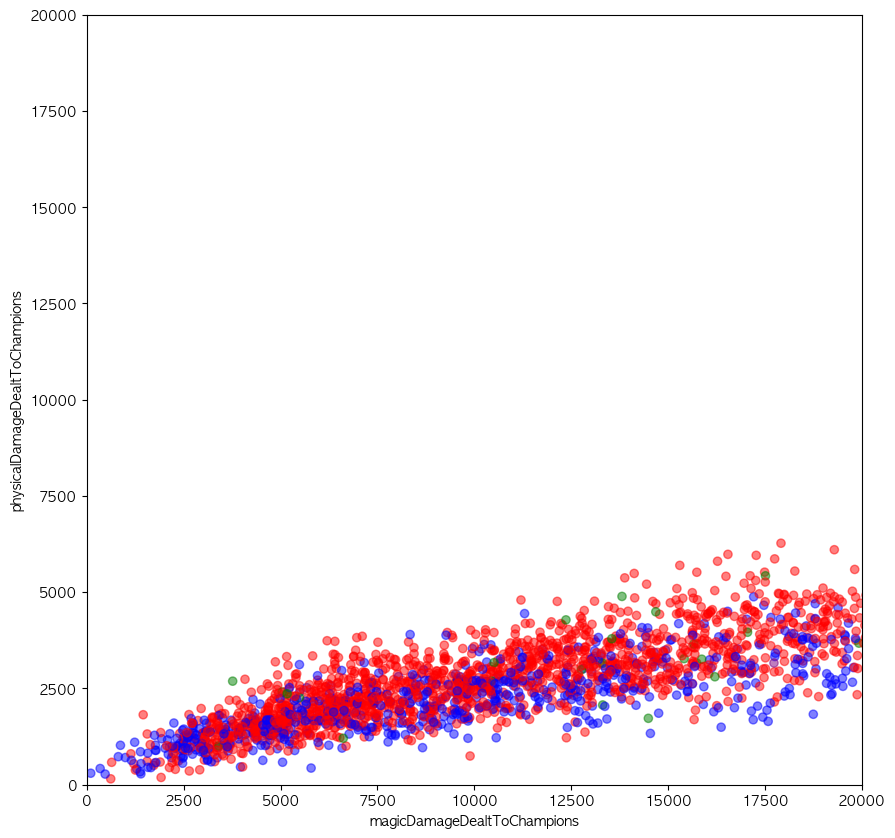

In [12]:
# 그웬 마법데미지, 물리데미지
gwen = result_df[result_df['championId'] == 887]
plt.figure(figsize=(10, 10))
plt.scatter(gwen['magicDamageDealtToChampions'], gwen['physicalDamageDealtToChampions'], c=gwen['color'], alpha=0.5)
plt.xlabel('magicDamageDealtToChampions')
plt.ylabel('physicalDamageDealtToChampions')
plt.xlim(0, 20000)
plt.ylim(0, 20000)
plt.show()


<Axes: >

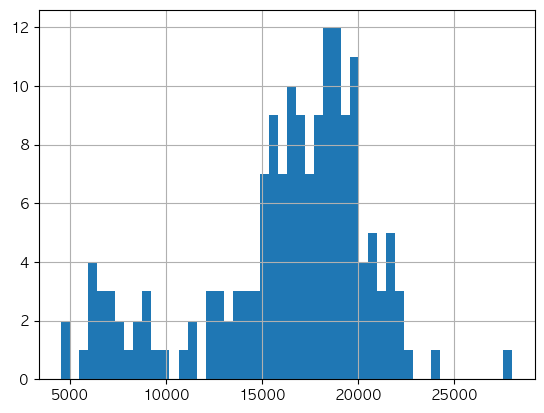

In [13]:
result_avg_df['totalDamageDealtToChampions'].hist(bins=50)

15821.712858926343


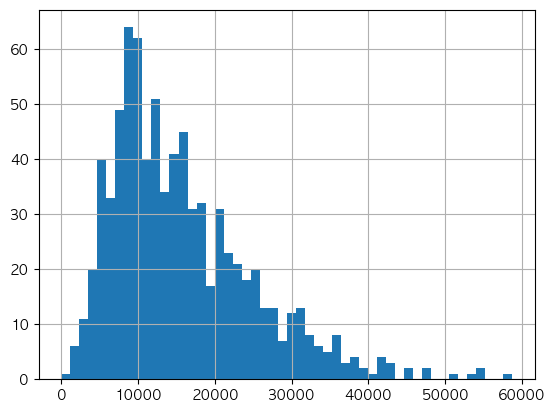

In [14]:
# 가렌 평균딜량
garen = result_df[result_df['championId'] == 86]
garen['totalDamageDealtToChampions'].hist(bins=50)
print(garen['totalDamageDealtToChampions'].mean())
plt.show()

In [15]:
# 평균딜 15000 미만인 챔프
low_champ_list = result_avg_df[result_avg_df['totalDamageDealtToChampions'] < 12000].index
for championId in low_champ_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])

알리스타
소라카
질리언
아무무
람머스
소나
잔나
카르마
타릭
블리츠크랭크
마오카이
레오나
노틸러스
룰루
세라핀
브라움
나미
유미
쓰레쉬
아이번
바드
라칸
렐
파이크
레나타 글라스크
밀리오


16596.82242436227


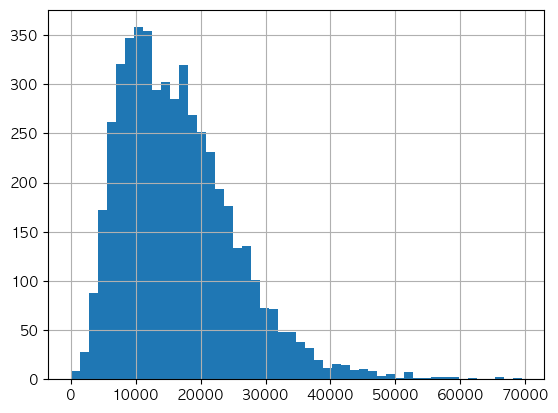

In [16]:
# 그라가스 평균딜
gragas = result_df[result_df['championId'] == 79]
gragas['totalDamageDealtToChampions'].hist(bins=50)
print(gragas['totalDamageDealtToChampions'].mean())

In [17]:
# 나서스 평균 총딜
nasus = result_df[result_df['championId'] == 75]
print(nasus['totalDamageDealtToChampions'].mean())
# 나서스 평균 물딜
print(nasus['physicalDamageDealtToChampions'].mean())
# 나서스 평균 마딜
print(nasus['magicDamageDealtToChampions'].mean())

15437.95
10511.877192982456
4717.16052631579


In [18]:
# 누누 평균 총딜
nunu = result_df[result_df['championId'] == 20]
print(nunu['totalDamageDealtToChampions'].mean())
# 누누 평균 물딜
print(nunu['physicalDamageDealtToChampions'].mean())
# 누누 평균 마딜
print(nunu['magicDamageDealtToChampions'].mean())

13571.628916987356
846.5492028587136
11991.089059923035


In [19]:
# 니코 평균 총딜
neeko = result_df[result_df['championId'] == 518]
print(neeko['totalDamageDealtToChampions'].mean())
# 니코 평균 물딜
print(neeko['physicalDamageDealtToChampions'].mean())
# 니코 평균 마딜
print(neeko['magicDamageDealtToChampions'].mean())

14102.262844036697
1276.0557339449542
12337.095412844037


In [20]:
# 다리우스 평균 총딜
darius = result_df[result_df['championId'] == 122]
print(darius['totalDamageDealtToChampions'].mean())
# 다리우스 평균 물딜
print(darius['physicalDamageDealtToChampions'].mean())
# 다리우스 평균 마딜
print(darius['magicDamageDealtToChampions'].mean())

14973.95067264574
12381.801793721974
33.209417040358744


In [21]:
#리산드라 평균 총딜
lissandra = result_df[result_df['championId'] == 127]
print(lissandra['totalDamageDealtToChampions'].mean())
#리산드라 평균 물딜
print(lissandra['physicalDamageDealtToChampions'].mean())
#리산드라 평균 마딜
print(lissandra['magicDamageDealtToChampions'].mean())

16921.408310249306
1322.1385041551246
15200.965650969529


In [22]:
# 말자하
malzahar = result_df[result_df['championId'] == 90]
print(malzahar['totalDamageDealtToChampions'].mean())

18113.976827094473


In [23]:
# 모데카이저
mordekaiser = result_df[result_df['championId'] == 82]
print(mordekaiser['totalDamageDealtToChampions'].mean())

18369.402384500747


In [24]:
# 바이
vi = result_df[result_df['championId'] == 254]
print(vi['totalDamageDealtToChampions'].mean())

13245.790697674418


In [25]:
# 벨베스
velkoz = result_df[result_df['championId'] == 161]
print(velkoz['totalDamageDealtToChampions'].mean())

20489.255464480873


In [26]:
# 볼리베어
volibear = result_df[result_df['championId'] == 106]
print(volibear['totalDamageDealtToChampions'].mean())

16057.78031212485


In [27]:
# 샤코
shaco = result_df[result_df['championId'] == 35]
print(shaco['totalDamageDealtToChampions'].mean())
# 샤코 평균 물딜
print(shaco['physicalDamageDealtToChampions'].mean())
# 샤코 평균 마딜
print(shaco['magicDamageDealtToChampions'].mean())

15659.911702577101
6493.847908745247
7267.2653147444025


In [28]:
# 세나
senna = result_df[result_df['championId'] == 235]
print(senna['totalDamageDealtToChampions'].mean())
# 세나 평균 물딜
print(senna['physicalDamageDealtToChampions'].mean())


12459.833333333334
11567.435081148564


In [29]:
# 세라핀
seraphine = result_df[result_df['championId'] == 147]
print(seraphine['totalDamageDealtToChampions'].mean())

9966.549303181699


## DealtPerMinute

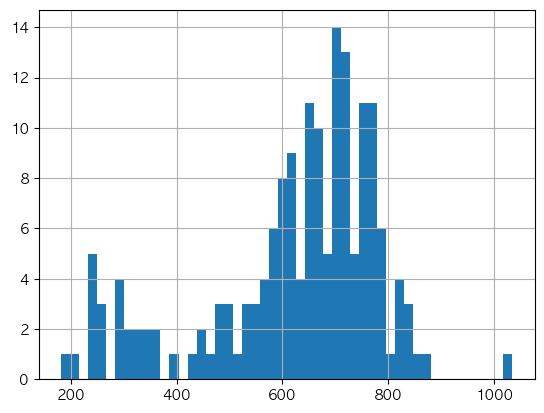

In [31]:
# avg dpm groupby championId
result_avg_df['dpm'] = result_df.groupby('championId')['dpm'].mean()
result_avg_df['dpm'].hist(bins=50)
plt.show()

In [33]:
# 다리우스
darius = result_df[result_df['championId'] == 122]
# dpm 평균
print(darius['dpm'].mean())

574.3762714019367


In [ ]:
# dpm info
result_avg_df['dpm'].describe()

count     168.000000
mean      622.624790
std       163.519283
min       182.125864
25%       564.777695
50%       663.334880
75%       729.900301
max      1034.147979
Name: dpm, dtype: float64

In [39]:
# dpm 하위 25%
low_dpm_list = result_avg_df[result_avg_df['dpm'] < 565].index

# dpm 상위 25%
high_dpm_list = result_avg_df[result_avg_df['dpm'] > 565].index

In [ ]:
print('low dpm')
for championId in low_dpm_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])

print('high dpm')
for championId in high_dpm_list:
    print(champ_df[champ_df['key'] == championId]['name'].values[0])

low dpm
알리스타
소라카
누누와 윌럼프
모르가나
질리언
아무무
람머스
소나
잔나
카르마
타릭
트런들
블리츠크랭크
녹턴
마오카이
자르반 4세
뽀삐
레오나
쉔
럭스
노틸러스
세주아니
룰루
세라핀
벨베스
브라움
탐 켄치
비에고
세나
바이
나미
유미
쓰레쉬
렉사이
아이번
바드
라칸
니코
렐
파이크
레나타 글라스크
밀리오
high dpm
애니
올라프
갈리오
트위스티드 페이트
신 짜오
우르곳
르블랑
블라디미르
피들스틱
케일
마스터 이
라이즈
사이온
시비르
티모
트리스타나
워윅
미스 포츈
애쉬
트린다미어
잭스
신지드
이블린
트위치
카서스
초가스
애니비아
샤코
문도 박사
카사딘
이렐리아
갱플랭크
코르키
베이가
스웨인
케이틀린
말파이트
카타리나
레넥톤
엘리스
오리아나
오공
브랜드
리 신
베인
럼블
카시오페아
스카너
하이머딩거
나서스
니달리
우디르
그라가스
판테온
이즈리얼
모데카이저
요릭
아칼리
케넨
가렌
말자하
탈론
리븐
코그모
제라스
쉬바나
아리
그레이브즈
피즈
볼리베어
렝가
바루스
빅토르
피오라
직스
드레이븐
헤카림
카직스
다리우스
제이스
리산드라
다이애나
퀸
신드라
아우렐리온 솔
케인
조이
자이라
카이사
나르
자크
야스오
벨코즈
탈리야
카밀
아크샨
진
킨드레드
제리
징크스
브라이어
루시안
제드
클레드
에코
키아나
아트록스
아지르
사미라
일라오이
칼리스타
자야
오른
사일러스
아펠리오스
벡스
요네
세트
릴리아
그웬
오로라
닐라
크산테
스몰더
흐웨이
나피리


In [41]:
# 스카너 평균 물딜
scarner = result_df[result_df['championId'] == 72]
print(scarner['physicalDamageDealtToChampions'].mean())
# 스카너 평균 마딜
print(scarner['magicDamageDealtToChampions'].mean())

# 스몰더 평균 물딜
smolder = result_df[result_df['championId'] == 202]
print(smolder['physicalDamageDealtToChampions'].mean())
# 스몰더 평균 마딜
print(smolder['magicDamageDealtToChampions'].mean())



9987.263650025046
4578.329270328936
15918.303947139628
1024.0079406480033


In [42]:
# 우디르 평균 물딜
udyr = result_df[result_df['championId'] == 77]
print(udyr['physicalDamageDealtToChampions'].mean())
# 우디르 평균 마딜
print(udyr['magicDamageDealtToChampions'].mean())

4622.908320982427
12037.969510904086


In [43]:
# 잭스 평균 물딜
jax = result_df[result_df['championId'] == 24]
print(jax['physicalDamageDealtToChampions'].mean())
# 잭스 평균 마딜
print(jax['magicDamageDealtToChampions'].mean())

9038.743338331988
7756.356442496251


In [44]:
# 카타리나 평균 물딜
katarina = result_df[result_df['championId'] == 55]
print(katarina['physicalDamageDealtToChampions'].mean())
# 카타리나 평균 마딜
print(katarina['magicDamageDealtToChampions'].mean())

#케일 평균 물딜
kayle = result_df[result_df['championId'] == 10]
print(kayle['physicalDamageDealtToChampions'].mean())
#케일 평균 마딜
print(kayle['magicDamageDealtToChampions'].mean())

2217.890775585131
16106.048646167967
6222.67175572519
10395.07251908397


In [45]:
# 코그모 평균 물딜
kogmaw = result_df[result_df['championId'] == 96]
print(kogmaw['physicalDamageDealtToChampions'].mean())
# 코그모 평균 마딜
print(kogmaw['magicDamageDealtToChampions'].mean())

2378.503256364713
19766.276050917702


In [46]:
# 크산테
ksante = result_df[result_df['championId'] == 134]
print(ksante['physicalDamageDealtToChampions'].mean())
print(ksante['magicDamageDealtToChampions'].mean())


1034.9309623430963
18142.684997011358


In [47]:
# 트위치
twitch = result_df[result_df['championId'] == 29]
print(twitch['physicalDamageDealtToChampions'].mean())
print(twitch['magicDamageDealtToChampions'].mean())

16263.500406834824
306.39625711960946
